In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ============================================================
# CELL 1 — Import Required Libraries
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# ============================================================
# CELL 2 — Locate the Dataset
# ============================================================

import os

for root, dirs, files in os.walk("/kaggle/input/datasets/ravikiranvarmap/somlap-data-set/SOMLAP DATASET.csv"):
    for file in files:
        print(os.path.join(root, file))

In [11]:
# ============================================================
# CELL 3 — Load SOMLAP Dataset
# ============================================================

DATA_PATH = "/kaggle/input/datasets/ravikiranvarmap/somlap-data-set/SOMLAP DATASET.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (51408, 109)


In [12]:
# ============================================================
# CELL 4 — Preview the Dataset
# ============================================================

display(df.head())

,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,Ics,Rta,Ovn,Idoem,Infoem,exehdradr,mach,nsec,tds,ptrst,stcnt,ohs,char,sig,majlv,minlv,codesize,initdatsize,uninitdatsize,adrentpt,cbase,dbase,ibase,secalign,filealign,majosver,minosver,majiver,miniver,majssver,minssver,win32vv,soi,soh,optcksum,ss,dllch,sosr,sosc,sohr,sohc,ldflg,ndirent,Text_mscfaddr,Text_secsize,Text_byteaddr,Text_datsize,Text_ptrrawdat,Text_ptrreloc,Text_ptrlinenum,Text_numrelocs,Text_numlinenums,Text_char,Text_entro,Idata_mscfaddr,Idata_secsize,Idata_byteaddr,Idata_datsize,Idata_ptrrawdat,Idata_ptrreloc,Idata_ptrlinenum,Idata_numrelocs,Idata_numlinenums,Idata_char,Idata_entro,Rsrc_mscfaddr,Rsrc_secsize,Rsrc_byteaddr,Rsrc_datsize,Rsrc_ptrrawdat,Rsrc_ptrreloc,Rsrc_ptrlinenum,Rsrc_numrelocs,Rsrc_numlinenums,Rsrc_char,Rsrc_entro,Data_mscfaddr,Data_secsize,Data_byteaddr,Data_datsize,Data_ptrrawdat,Data_ptrreloc,Data_ptrlinenum,Data_numrelocs,Data_numlinenums,Data_char,Data_entro,bss_phyaddr,bss_virsize,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1,class
0,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,240,34404,6,1,0,0,240,34,523,14,13,47104,32256,0,48992,4096,0,0,0,0,10,0,10,0,6,0,0,98304,1024,90020,3,49504,524288,8192,1048576,4096,0,16,47056,47056,4096,47104,1024,0,0,0,0,1610612768,6.063171,0,0,0,0,0,0,0,0,0,0,0.0,2072,2072,90112,2560,75776,0,0,0,0,1073741888,3.735720,1800,1800,81920,512,73728,0,0,0,0,3221225536,0.759622,0,0,0,0,0,0,0.0,0,0,0,0,0
1,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,248,34404,8,1,0,0,240,34,523,14,13,2234368,1979904,512,639680,4096,0,0,0,0,10,0,10,0,10,0,0,4235264,1024,4252145,2,49600,524288,57344,1048576,4096,0,16,2234280,2234280,4096,2234368,1024,0,0,0,0,1610612768,6.372906,0,0,0,0,0,0,0,0,0,0,0.0,1245096,1245096,2969600,1245184,2934784,0,0,0,0,1073741888,4.903914,21848,21848,2834432,6144,2823680,0,0,0,0,3221225536,3.182630,0,0,0,0,0,0,0.0,0,0,0,0,0
2,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,232,34404,7,1,0,0,240,34,523,14,13,367104,700416,0,353728,4096,0,0,0,0,10,0,10,0,10,0,0,1081344,1024,1129939,2,49504,524288,8192,1048576,4096,0,16,366636,366636,4096,367104,1024,0,0,0,0,1610612768,6.382614,0,0,0,0,0,0,0,0,0,0,0.0,536416,536416,540672,536576,525824,0,0,0,0,1073741888,2.518823,18336,18336,503808,15360,498176,0,0,0,0,3221225536,3.873805,0,0,0,0,0,0,0.0,0,0,0,0,0
3,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,232,34404,6,1,0,0,240,34,523,14,13,4608,13824,0,6128,4096,0,0,0,0,10,0,10,0,10,0,0,36864,1024,25808,2,49504,524288,8192,1048576,4096,0,16,4208,4208,4096,4608,1024,0,0,0,0,1610612768,5.777021,0,0,0,0,0,0,0,0,0,0,0.0,7368,7368,24576,7680,10240,0,0,0,0,1073741888,3.756737,1536,1536,16384,512,9216,0,0,0,0,3221225536,0.301407,0,0,0,0,0,0,0.0,0,0,0,0,0
4,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,248,34404,6,0,0,0,240,34,523,14,13,109568,152576,0,109648,4096,0,0,0,0,10,0,10,0,10,0,0,274432,1024,315743,2,49504,524288,69632,1048576,4096,0,16,109109,109109,4096,109568,1024,0,0,0,0,1610612768,6.338657,0,0,0,0,0,0,0,0,0,0,0.0,105696,105696,163840,105984,147456,0,0,0,0,1073741888,7.359239,11732,11732,147456,3072,141824,0,0,0,0,3221225536,1.827258,0,0,0,0,0,0,0.0,0,0,0,0,0


In [13]:
# ============================================================
# CELL 5 — Dataset Dimensions
# ============================================================

n_samples, n_columns = df.shape
n_features = n_columns - 1

print(f"Number of samples       : {n_samples:,}")
print(f"Number of columns       : {n_columns:,}")
print(f"Number of input features: {n_features:,}")

Number of samples       : 51,408
Number of columns       : 109
Number of input features: 108


In [14]:
# ============================================================
# CELL 6 — Column Names
# ============================================================

print("Dataset columns:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:3}. {col}")

Dataset columns:

  1. blp
  2. Fp
  3. Rn
  4. Prhdr
  5. Minpar
  6. Maxpar
  7. Ivalss
  8. Ivalsp
  9. doscksum
 10. Iip
 11. Ics
 12. Rta
 13. Ovn
 14. Idoem
 15. Infoem
 16. exehdradr
 17. mach
 18. nsec
 19. tds
 20. ptrst
 21. stcnt
 22. ohs
 23. char
 24. sig
 25. majlv
 26. minlv
 27. codesize
 28. initdatsize
 29. uninitdatsize
 30. adrentpt
 31. cbase
 32. dbase
 33. ibase
 34. secalign
 35. filealign
 36. majosver
 37. minosver
 38. majiver
 39. miniver
 40. majssver
 41. minssver
 42. win32vv
 43. soi
 44. soh
 45. optcksum
 46. ss
 47. dllch
 48. sosr
 49. sosc
 50. sohr
 51. sohc
 52. ldflg
 53. ndirent
 54. Text_mscfaddr
 55. Text_secsize
 56. Text_byteaddr
 57. Text_datsize
 58. Text_ptrrawdat
 59. Text_ptrreloc
 60. Text_ptrlinenum
 61. Text_numrelocs
 62. Text_numlinenums
 63. Text_char
 64. Text_entro 
 65. Idata_mscfaddr
 66. Idata_secsize
 67. Idata_byteaddr
 68. Idata_datsize
 69. Idata_ptrrawdat
 70. Idata_ptrreloc
 71. Idata_ptrlinenum
 72. Idata_numrelocs
 73

In [15]:
# ============================================================
# CELL 7 — Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51408 entries, 0 to 51407
Columns: 109 entries, blp to class
dtypes: float64(5), int64(104)
memory usage: 42.8 MB


In [16]:
# ============================================================
# CELL 8 — Statistical Summary
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
blp,51408.0,171.834034,7.838131e+02,0.0,144.0,144.0,144.0,2.954000e+04
Fp,51408.0,32.985780,7.786418e+02,0.0,3.0,3.0,3.0,4.122500e+04
Rn,51408.0,29.860819,7.829817e+02,0.0,0.0,0.0,0.0,4.048100e+04
Prhdr,51408.0,29.889823,7.444180e+02,0.0,4.0,4.0,4.0,4.992300e+04
Minpar,51408.0,23.998541,6.621999e+02,0.0,0.0,0.0,0.0,3.032400e+04
...,...,...,...,...,...,...,...,...
bss_phyaddr.1,51408.0,35.873541,6.681986e+03,0.0,0.0,0.0,0.0,1.484825e+06
bss_virsize.1,51408.0,35.873541,6.681986e+03,0.0,0.0,0.0,0.0,1.484825e+06
bss_viraddr.1,51408.0,0.239029,3.128937e+01,0.0,0.0,0.0,0.0,4.096000e+03
bss_char.1,51408.0,219310.022409,2.870812e+07,0.0,0.0,0.0,0.0,3.758097e+09


In [17]:
# ============================================================
# CELL 9 — Identify Target Column
# ============================================================

TARGET_COLUMN = "class"

print("Target column:", TARGET_COLUMN)
print("Target data type:", df[TARGET_COLUMN].dtype)
print("Number of unique classes:", df[TARGET_COLUMN].nunique())

print("\nUnique class labels:")
print(sorted(df[TARGET_COLUMN].unique()))

Target column: class
Target data type: int64
Number of unique classes: 2

Unique class labels:
[np.int64(0), np.int64(1)]


In [18]:
# ============================================================
# CELL 10 — Separate Features and Target
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)

print("\nNumber of features:", X.shape[1])
print("Number of samples :", X.shape[0])

Feature matrix shape: (51408, 108)
Target vector shape : (51408,)

Number of features: 108
Number of samples : 51408


In [19]:
# ============================================================
# CELL 11 — Feature Data Types
# ============================================================

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical features :", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

if categorical_features:
    print("\nCategorical features:")
    print(categorical_features)
else:
    print("\nNo categorical input features found.")

Number of numerical features : 108
Number of categorical features: 0

No categorical input features found.


In [20]:
# ============================================================
# CELL 12 — Missing Value Analysis
# ============================================================

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

if missing_summary.empty:
    print("No missing values were found in the dataset.")
else:
    display(missing_summary)

No missing values were found in the dataset.


In [21]:
# ============================================================
# CELL 13 — Duplicate Row Analysis
# ============================================================

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage    : {duplicate_percentage:.4f}%")

Number of duplicate rows: 14,367
Duplicate percentage    : 27.9470%


In [22]:
# ============================================================
# CELL 14 — Dataset Summary Table
# ============================================================

summary_data = {
    "Property": [
        "Dataset Name",
        "Number of Samples",
        "Number of Input Features",
        "Total Columns",
        "Target Column",
        "Number of Classes",
        "Numerical Features",
        "Categorical Features",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        "SOMLAP Dataset",
        f"{len(df):,}",
        f"{X.shape[1]:,}",
        f"{df.shape[1]:,}",
        TARGET_COLUMN,
        f"{df[TARGET_COLUMN].nunique():,}",
        f"{len(numeric_features):,}",
        f"{len(categorical_features):,}",
        f"{df.isnull().sum().sum():,}",
        f"{duplicate_count:,}"
    ]
}

dataset_summary = pd.DataFrame(summary_data)

display(dataset_summary)

,Property,Value
0,Dataset Name,SOMLAP Dataset
1,Number of Samples,"51,408"
2,Number of Input Features,108
3,Total Columns,109
4,Target Column,class
5,Number of Classes,2
6,Numerical Features,108
7,Categorical Features,0
8,Missing Values,0
9,Duplicate Rows,"14,367"


In [23]:
# ============================================================
# CELL 15 — Data Type Distribution
# ============================================================

dtype_summary = df.dtypes.value_counts().reset_index()
dtype_summary.columns = ["Data_Type", "Number_of_Columns"]

display(dtype_summary)

,Data_Type,Number_of_Columns
0,int64,104
1,float64,5


In [24]:
# ============================================================
# CELL 16 — Class Distribution
# ============================================================

class_counts = y.value_counts().sort_index()

print("Class counts:\n")
display(class_counts.to_frame("Count"))

Class counts:



,Count
class,
0,31600
1,19808


In [25]:
# ============================================================
# CELL 17 — Class Distribution with Percentages
# ============================================================

class_distribution = pd.DataFrame({
    "Count": y.value_counts().sort_index(),
    "Percentage": y.value_counts(normalize=True).sort_index() * 100
})

class_distribution["Percentage"] = class_distribution["Percentage"].round(2)

display(class_distribution)

,Count,Percentage
class,,
0,31600,61.47
1,19808,38.53


In [26]:
# ============================================================
# CELL 18 — Majority-to-Minority Ratio
# ============================================================

majority_count = class_counts.max()
minority_count = class_counts.min()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

ratio = majority_count / minority_count

print(f"Majority class : {majority_class}")
print(f"Majority count : {majority_count:,}")

print(f"\nMinority class : {minority_class}")
print(f"Minority count : {minority_count:,}")

print(f"\nMajority-to-minority ratio: {ratio:.2f}:1")

Majority class : 0
Majority count : 31,600

Minority class : 1
Minority count : 19,808

Majority-to-minority ratio: 1.60:1


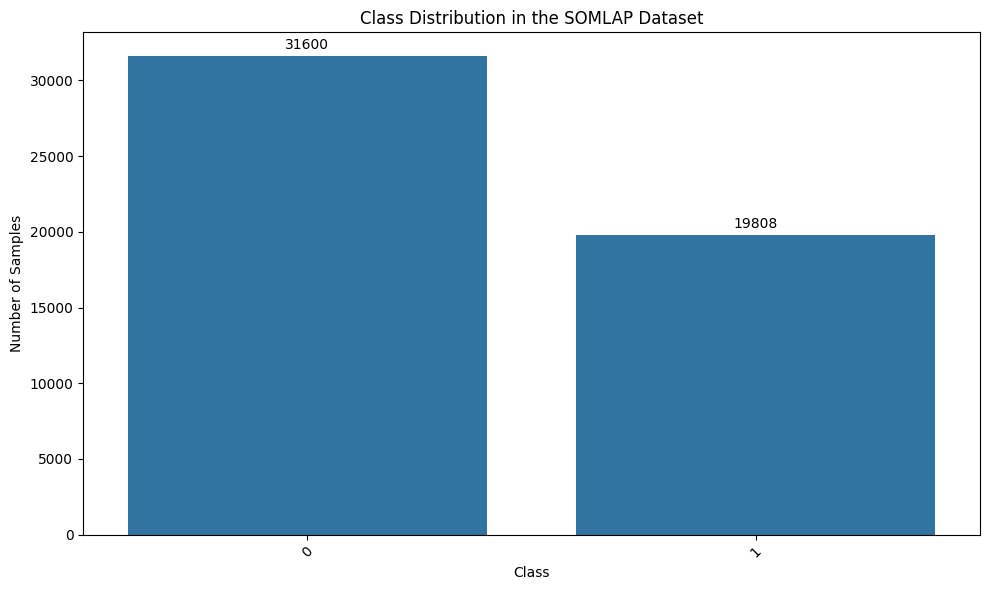

In [27]:
# ============================================================
# CELL 19 — Class Distribution Bar Plot
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution["Count"]
)

plt.title("Class Distribution in the SOMLAP Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

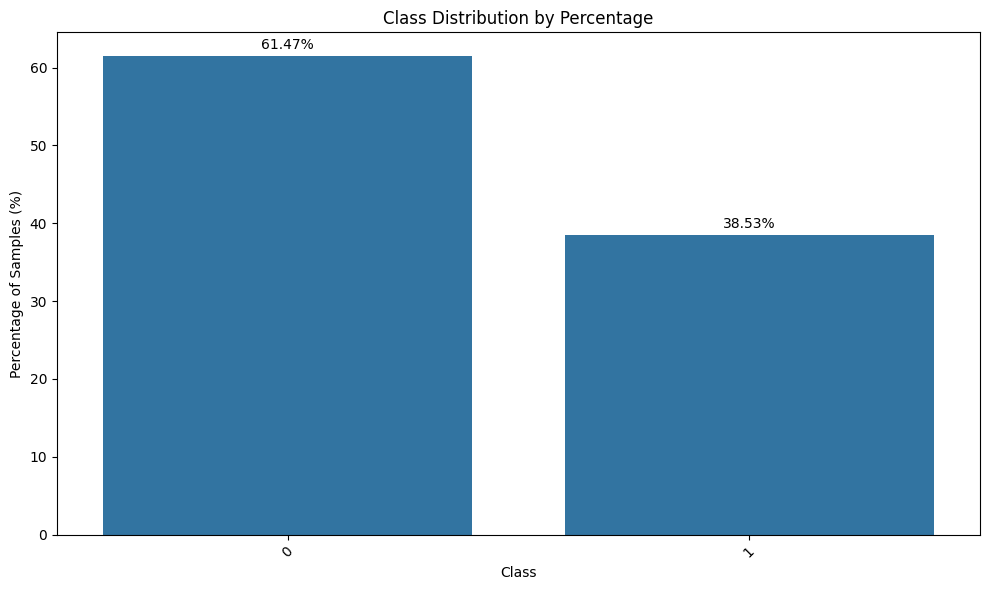

In [28]:
# ============================================================
# CELL 20 — Class Distribution by Percentage
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=class_distribution.index.astype(str),
    y=class_distribution["Percentage"]
)

plt.title("Class Distribution by Percentage")
plt.xlabel("Class")
plt.ylabel("Percentage of Samples (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# CELL 21 — Class Balance Statistics
# ============================================================

balance_stats = {
    "Number of Classes": y.nunique(),
    "Largest Class Count": int(majority_count),
    "Smallest Class Count": int(minority_count),
    "Majority Class": majority_class,
    "Minority Class": minority_class,
    "Majority-to-Minority Ratio": round(ratio, 4),
    "Largest Class Percentage": round(
        (majority_count / len(y)) * 100, 2
    ),
    "Smallest Class Percentage": round(
        (minority_count / len(y)) * 100, 2
    )
}

balance_summary = pd.DataFrame(
    balance_stats.items(),
    columns=["Metric", "Value"]
)

display(balance_summary)

,Metric,Value
0,Number of Classes,2.0000
1,Largest Class Count,31600.0000
2,Smallest Class Count,19808.0000
3,Majority Class,0.0000
4,Minority Class,1.0000
5,Majority-to-Minority Ratio,1.5953
6,Largest Class Percentage,61.4700
7,Smallest Class Percentage,38.5300


In [30]:
# ============================================================
# CELL 22 — Class Distribution of Duplicate Rows
# ============================================================

duplicate_mask = df.duplicated(keep=False)

duplicate_rows = df[duplicate_mask]

print(f"Total rows involved in duplication: {len(duplicate_rows):,}")

print("\nClass distribution among duplicated rows:")
duplicate_class_counts = duplicate_rows[TARGET_COLUMN].value_counts().sort_index()

display(
    duplicate_class_counts.to_frame("Count")
)

Total rows involved in duplication: 25,633

Class distribution among duplicated rows:


,Count
class,
0,23647
1,1986


In [31]:
# ============================================================
# CELL 23 — Duplicate Rows: Class Percentages
# ============================================================

duplicate_class_distribution = pd.DataFrame({
    "Count": duplicate_rows[TARGET_COLUMN].value_counts().sort_index(),
    "Percentage": (
        duplicate_rows[TARGET_COLUMN]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

duplicate_class_distribution["Percentage"] = (
    duplicate_class_distribution["Percentage"].round(2)
)

display(duplicate_class_distribution)

,Count,Percentage
class,,
0,23647,92.25
1,1986,7.75


In [32]:
# ============================================================
# CELL 24 — Frequency of Exact Duplicate Groups
# ============================================================

duplicate_group_sizes = (
    df.groupby(list(df.columns), dropna=False)
      .size()
      .reset_index(name="Frequency")
)

duplicate_groups = duplicate_group_sizes[
    duplicate_group_sizes["Frequency"] > 1
].copy()

print(f"Number of unique duplicated groups: {len(duplicate_groups):,}")

print("\nFrequency distribution of duplicated groups:")
display(
    duplicate_groups["Frequency"]
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Repetitions")
    .reset_index(name="Number_of_Groups")
)

Number of unique duplicated groups: 11,266

Frequency distribution of duplicated groups:


,Number_of_Repetitions,Number_of_Groups
0,2,9825
1,3,402
2,4,854
3,5,52
4,6,70
5,7,19
6,8,12
7,9,3
8,10,6
9,11,6


In [33]:
# ============================================================
# CELL 25 — Most Frequently Repeated Samples
# ============================================================

top_duplicate_groups = duplicate_groups.sort_values(
    "Frequency",
    ascending=False
)

display(
    top_duplicate_groups.head(10)
)

,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,Ics,Rta,Ovn,Idoem,Infoem,exehdradr,mach,nsec,tds,ptrst,stcnt,ohs,char,sig,majlv,minlv,codesize,initdatsize,uninitdatsize,adrentpt,cbase,dbase,ibase,secalign,filealign,majosver,minosver,majiver,miniver,majssver,minssver,win32vv,soi,soh,optcksum,ss,dllch,sosr,sosc,sohr,sohc,ldflg,ndirent,Text_mscfaddr,Text_secsize,Text_byteaddr,Text_datsize,Text_ptrrawdat,Text_ptrreloc,Text_ptrlinenum,Text_numrelocs,Text_numlinenums,Text_char,Text_entro,Idata_mscfaddr,Idata_secsize,Idata_byteaddr,Idata_datsize,Idata_ptrrawdat,Idata_ptrreloc,Idata_ptrlinenum,Idata_numrelocs,Idata_numlinenums,Idata_char,Idata_entro,Rsrc_mscfaddr,Rsrc_secsize,Rsrc_byteaddr,Rsrc_datsize,Rsrc_ptrrawdat,Rsrc_ptrreloc,Rsrc_ptrlinenum,Rsrc_numrelocs,Rsrc_numlinenums,Rsrc_char,Rsrc_entro,Data_mscfaddr,Data_secsize,Data_byteaddr,Data_datsize,Data_ptrrawdat,Data_ptrreloc,Data_ptrlinenum,Data_numrelocs,Data_numlinenums,Data_char,Data_entro,bss_phyaddr,bss_virsize,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1,class,Frequency
27226,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,224,34404,4,0,0,0,240,35,523,9,0,54784,27136,0,11128,4096,0,0,0,0,5,2,0,0,5,2,0,94208,1024,0,3,32768,1048576,4096,1048576,4096,0,16,54300,54300,4096,54784,1024,0,0,0,0,1610612768,6.366763,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0.000000,13796,13796,73728,5632,66560,0,0,0,0,3221225536,1.856023,0,0,0,0,0,0,0.0,0,0,0,0,0,29
4273,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,128,332,3,0,0,0,224,258,267,8,0,30208,133632,0,161040,147456,8192,0,0,0,4,0,0,0,4,0,0,188416,512,205192,2,34112,1048576,4096,1048576,4096,0,16,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,0.0,132720,132720,8192,133120,512,0,0,0,0,1073741888,5.115693,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.0,0,0,0,0,1,25
29532,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,240,34404,6,0,0,0,240,34,523,10,0,56832,44544,0,12668,4096,0,0,0,0,5,2,0,0,5,2,0,131072,1024,166919,3,33088,1048576,4096,1048576,4096,0,16,56670,56670,4096,56832,1024,0,0,0,0,1610612768,6.402325,0,0,0,0,0,0,0,0,0,0,0.0,20644,20644,102400,20992,80384,0,0,0,0,1073741888,5.556221,16516,16516,77824,5120,72192,0,0,0,0,3221225536,1.919196,0,0,0,0,0,0,0.0,0,0,0,0,0,24
8788,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,128,332,3,0,0,0,224,258,267,8,0,774144,220672,0,781902,8192,786432,0,0,0,4,0,0,0,4,0,0,1015808,512,0,2,34112,1048576,4096,1048576,4096,0,16,773716,773716,8192,774144,512,0,0,0,0,1610612768,4.065159,0,0,0,0,0,0,0,0,0,0,0.0,219792,219792,786432,220160,774656,0,0,0,0,1073741888,6.330312,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.0,0,0,0,0,1,24
18947,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,128,332,4,0,0,0,224,270,267,8,0,14848,4096,0,22926,8192,24576,0,0,0,4,0,0,0,4,0,0,49152,1024,0,2,1344,1048576,4096,1048576,4096,0,16,14740,14740,8192,14848,1024,0,0,0,0,1610612768,5.742682,0,0,0,0,0,0,0,0,0,0,0.0,2680,2680,32768,3072,16384,0,0,0,0,1073741888,3.698584,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.0,0,0,0,0,1,21
5817,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,128,332,3,0,0,0,224,258,267,8,0,78848,7680,0,86974,8192,90112,0,0,0,4,0,0,0,4,0,0,106496,512,0,2,34112,1048576,4096,1048576,4096,0,16,78788,78788,8192,78848,512,0,0,0,0,1610612768,6.017154,0,0,0,0,0,0,0,0,0,0,0.0,7096,7096,90112,7168,79360,0,0,0,0,1073741888,4.553021,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.0,0,0,0,0,1,20
4266,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,128,332,3,0,0,0,224,258,267,8,0,30208,133632,0,161040,147456,8192,0,0,0,4,0,0,0,4,0,0,188416,512,205192,2,34112,1048576,4096,1048576,4096,0,16,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,0.0,132720,132720,8192,133120,512,0,0,0,0,1073741888,5.115650,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0,0,0.0,0,0,0,0,1,18
22684,144,3,0,4,0,65535,0,184,0,0,0,64,0,0,0,184,332,2,1,0,0,224,8450,267,14,13,0,1536,0,0,4096,4096,0,0,0,10,0,10,0,10,0,0,12288,512,55229,3,1344,262144,4096,1048576,4096,0,16,176,176,4096,512,512,0,0,0,0,1073741888,1.707171,0,0,0,0,0,0,0,0,0,0,0.0,1024,1024,8192,

In [34]:
# ============================================================
# CELL 26 — Duplicate Analysis Summary
# ============================================================

unique_rows = df.drop_duplicates().shape[0]

duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Unique rows",
        "Rows beyond first occurrence",
        "Rows involved in duplicated groups",
        "Duplicate percentage"
    ],
    "Value": [
        len(df),
        unique_rows,
        df.duplicated().sum(),
        duplicate_mask.sum(),
        f"{(df.duplicated().sum() / len(df)) * 100:.2f}%"
    ]
})

display(duplicate_summary)

,Metric,Value
0,Total rows,51408
1,Unique rows,37041
2,Rows beyond first occurrence,14367
3,Rows involved in duplicated groups,25633
4,Duplicate percentage,27.95%


In [35]:
# ============================================================
# CELL 27 — Prepare Features for PCA
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Keep only numerical input features
X_numeric = X.select_dtypes(include=np.number).copy()

print("Original feature shape:", X_numeric.shape)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

print("Scaled feature matrix shape:", X_scaled.shape)

Original feature shape: (51408, 108)
Scaled feature matrix shape: (51408, 108)


In [36]:
# ============================================================
# CELL 28 — PCA Explained Variance
# ============================================================

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(
    f"Variance explained by first 2 components: "
    f"{cumulative_variance[1] * 100:.2f}%"
)

print(
    f"Variance explained by first 10 components: "
    f"{cumulative_variance[9] * 100:.2f}%"
)

Variance explained by first 2 components: 18.05%
Variance explained by first 10 components: 53.25%


In [37]:
# ============================================================
# CELL 29 — PCA 2D Representation
# ============================================================

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "class": y.values
})

print("PCA representation shape:", pca_df.shape)

display(pca_df.head())

PCA representation shape: (51408, 3)


,PC1,PC2,class
0,-0.124704,-0.077031,0
1,-0.066642,-0.180733,0
2,-0.101288,-0.090997,0
3,-0.121534,-0.070115,0
4,-0.168804,-0.183581,0


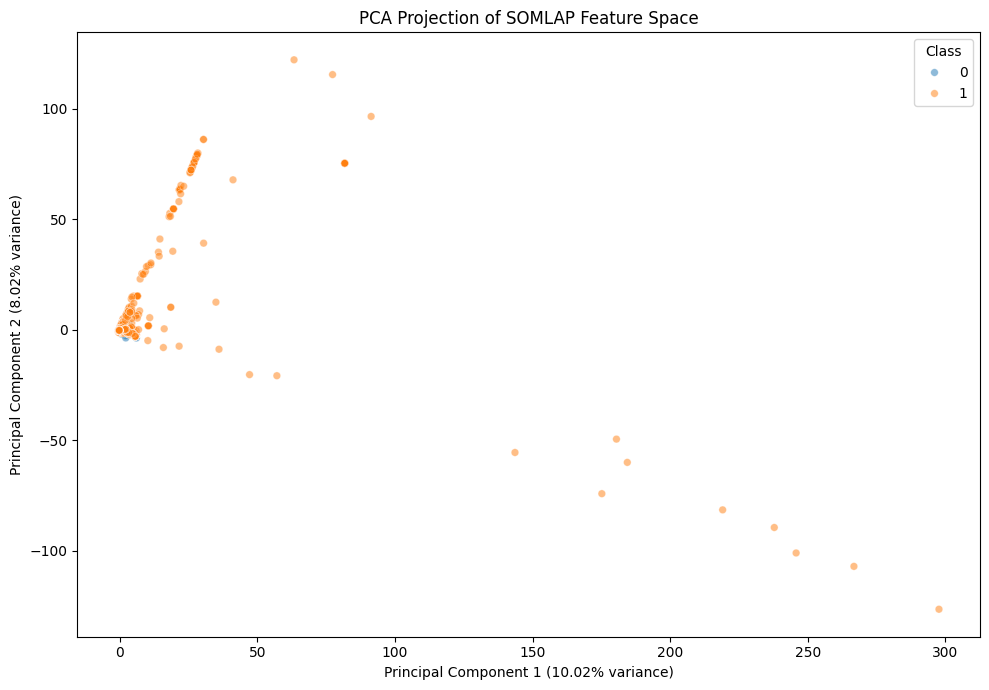

In [38]:
# ============================================================
# CELL 30 — PCA Feature-Space Visualization
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="class",
    alpha=0.5,
    s=30
)

plt.title("PCA Projection of SOMLAP Feature Space")
plt.xlabel(
    f"Principal Component 1 "
    f"({pca_2d.explained_variance_ratio_[0] * 100:.2f}% variance)"
)
plt.ylabel(
    f"Principal Component 2 "
    f"({pca_2d.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# CELL 31 — PCA Class-wise Statistics
# ============================================================

pca_class_summary = (
    pca_df
    .groupby("class")[["PC1", "PC2"]]
    .agg(["mean", "std", "min", "max"])
)

display(pca_class_summary)

PC1                                       PC2            \
           mean       std       min         max      mean       std   
class                                                                 
0     -0.064644  0.217815 -0.514480    6.044599 -0.010675  0.214292   
1      0.103127  5.292194 -0.475175  297.702662  0.017029  4.734616   

                               
              min         max  
class                          
0       -3.783485    6.893501  
1     -126.423511  122.026241

In [40]:
# ============================================================
# CELL 32 — PCA Class Centroids
# ============================================================

pca_centroids = (
    pca_df
    .groupby("class")[["PC1", "PC2"]]
    .mean()
)

display(pca_centroids)

,PC1,PC2
class,,
0,-0.064644,-0.010675
1,0.103127,0.017029


In [41]:
# ============================================================
# CELL 33 — Distance Between Class Centroids
# ============================================================

from scipy.spatial.distance import euclidean

centroid_distance = euclidean(
    pca_centroids.loc[0],
    pca_centroids.loc[1]
)

print(f"Euclidean distance between class centroids: {centroid_distance:.4f}")

Euclidean distance between class centroids: 0.1700


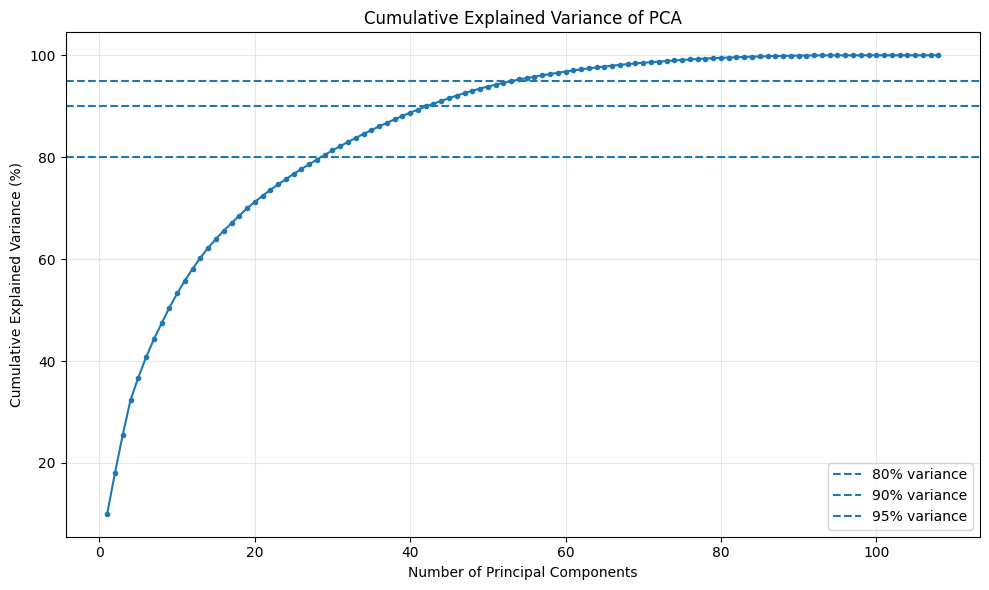

In [42]:
# ============================================================
# CELL 34 — PCA Cumulative Explained Variance
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o",
    markersize=3
)

plt.axhline(80, linestyle="--", label="80% variance")
plt.axhline(90, linestyle="--", label="90% variance")
plt.axhline(95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance of PCA")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# CELL 35 — Feature Statistics
# ============================================================

feature_stats = pd.DataFrame({
    "Data_Type": X.dtypes,
    "Unique_Values": X.nunique(),
    "Missing_Values": X.isnull().sum(),
    "Mean": X.mean(),
    "Std": X.std(),
    "Min": X.min(),
    "Median": X.median(),
    "Max": X.max()
})

display(feature_stats)

,Data_Type,Unique_Values,Missing_Values,Mean,Std,Min,Median,Max
blp,int64,46,0,171.834034,7.838131e+02,0.0,144.0,2.954000e+04
Fp,int64,27,0,32.985780,7.786418e+02,0.0,3.0,4.122500e+04
Rn,int64,19,0,29.860819,7.829817e+02,0.0,0.0,4.048100e+04
Prhdr,int64,22,0,29.889823,7.444180e+02,0.0,4.0,4.992300e+04
Minpar,int64,22,0,23.998541,6.621999e+02,0.0,0.0,3.032400e+04
...,...,...,...,...,...,...,...,...
bss_entro,float64,7,0,0.000421,4.365128e-02,0.0,0.0,6.332520e+00
bss_phyaddr.1,int64,4,0,35.873541,6.681986e+03,0.0,0.0,1.484825e+06
bss_virsize.1,int64,4,0,35.873541,6.681986e+03,0.0,0.0,1.484825e+06
bss_viraddr.1,int64,2,0,0.239029,3.128937e+01,0.0,0.0,4.096000e+03


In [44]:
# ============================================================
# CELL 36 — Feature Range Analysis
# ============================================================

feature_stats["Range"] = (
    feature_stats["Max"] - feature_stats["Min"]
)

range_summary = (
    feature_stats[["Min", "Max", "Range"]]
    .sort_values("Range", ascending=False)
)

display(range_summary.head(20))

,Min,Max,Range
cbase,0.0,4.294967e+09,4.294967e+09
stcnt,0.0,4.294967e+09,4.294967e+09
sohr,0.0,4.294967e+09,4.294967e+09
optcksum,0.0,4.294967e+09,4.294967e+09
Text_char,0.0,4.294967e+09,4.294967e+09
ldflg,0.0,4.294967e+09,4.294967e+09
Data_ptrreloc,0.0,4.294932e+09,4.294932e+09
Text_ptrlinenum,0.0,4.294923e+09,4.294923e+09
ptrst,0.0,4.283477e+09,4.283477e+09
Text_ptrreloc,0.0,4.269998e+09,4.269998e+09


In [45]:
# ============================================================
# CELL 37 — Feature Variance Analysis
# ============================================================

feature_variance = (
    X.var()
    .sort_values(ascending=False)
    .to_frame("Variance")
)

display(feature_variance.head(20))

,Variance
Data_char,2.557008e+18
Idata_char,7.964849e+17
bss_char,5.543365e+17
Text_char,4.573855e+17
Rsrc_char,2.617347e+17
ptrst,1.336917e+16
optcksum,7.716711e+15
stcnt,6.449201e+15
ldflg,4.914911e+15
initdatsize,3.765695e+15


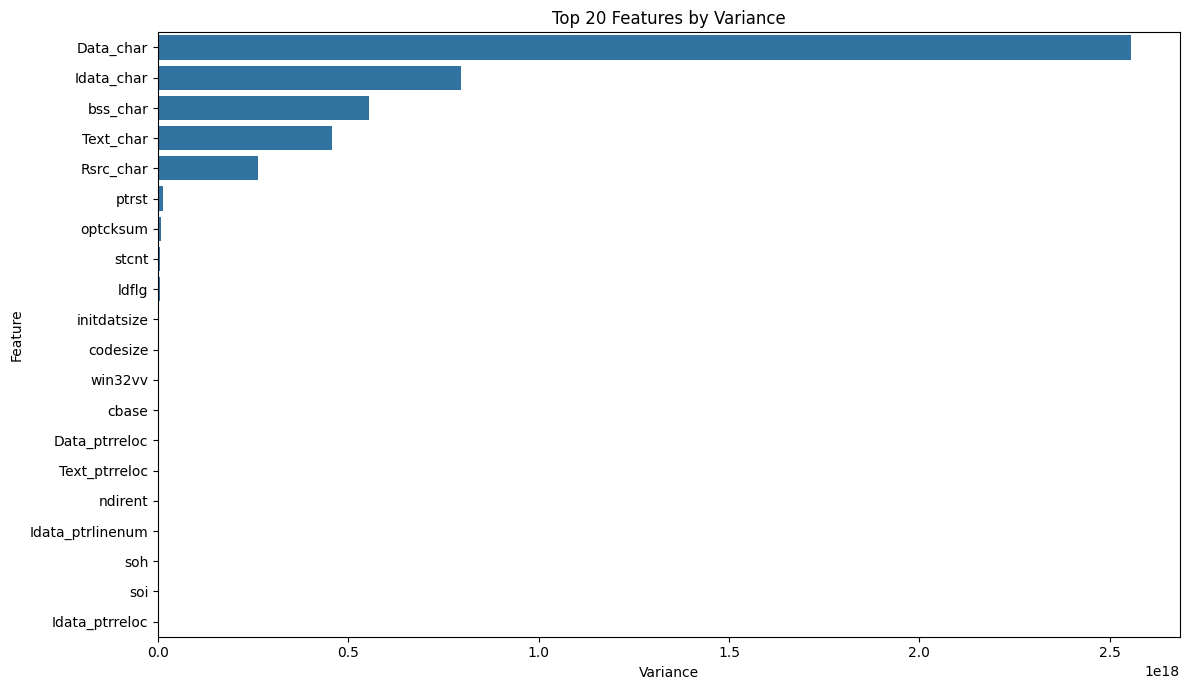

In [46]:
# ============================================================
# CELL 38 — Top 20 Features by Variance
# ============================================================

top_variance = feature_variance.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_variance["Variance"].values,
    y=top_variance.index
)

plt.title("Top 20 Features by Variance")
plt.xlabel("Variance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

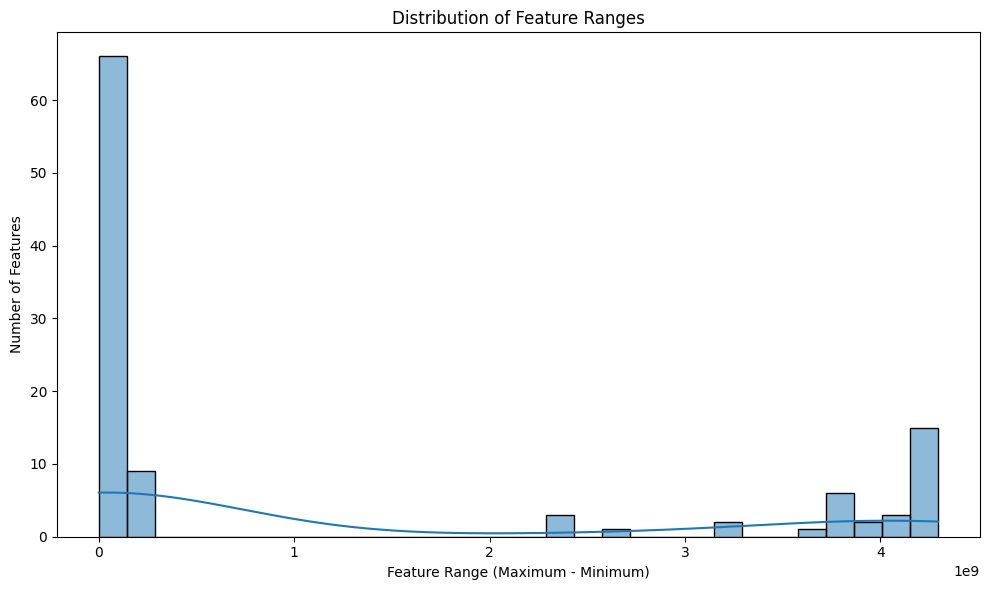

In [47]:
# ============================================================
# CELL 39 — Distribution of Feature Ranges
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    feature_stats["Range"],
    bins=30,
    kde=True
)

plt.title("Distribution of Feature Ranges")
plt.xlabel("Feature Range (Maximum - Minimum)")
plt.ylabel("Number of Features")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# CELL 40 — Duplicate Rate by Class
# ============================================================

class_duplicate_analysis = pd.DataFrame({
    "Total_Samples": y.value_counts().sort_index(),
    "Rows_In_Duplicate_Groups": (
        duplicate_rows[TARGET_COLUMN]
        .value_counts()
        .sort_index()
    )
}).fillna(0)

class_duplicate_analysis["Unique_or_NonDuplicated"] = (
    class_duplicate_analysis["Total_Samples"]
    - class_duplicate_analysis["Rows_In_Duplicate_Groups"]
)

class_duplicate_analysis["Duplicate_Rate_%"] = (
    class_duplicate_analysis["Rows_In_Duplicate_Groups"]
    / class_duplicate_analysis["Total_Samples"]
    * 100
).round(2)

display(class_duplicate_analysis)

,Total_Samples,Rows_In_Duplicate_Groups,Unique_or_NonDuplicated,Duplicate_Rate_%
class,,,,
0,31600,23647,7953,74.83
1,19808,1986,17822,10.03


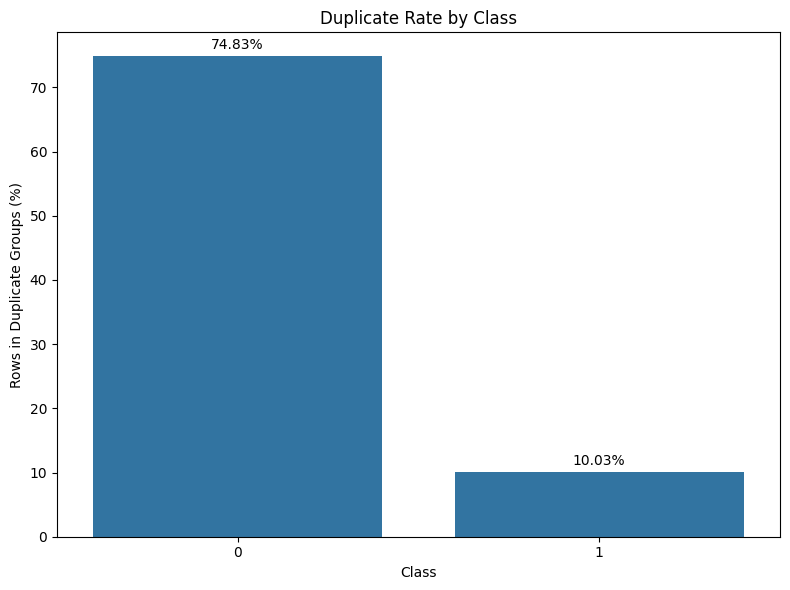

In [49]:
# ============================================================
# CELL 41 — Duplicate Rate by Class
# ============================================================

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=class_duplicate_analysis.index.astype(str),
    y=class_duplicate_analysis["Duplicate_Rate_%"]
)

plt.title("Duplicate Rate by Class")
plt.xlabel("Class")
plt.ylabel("Rows in Duplicate Groups (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# CELL 42 — Feature Cardinality Analysis
# ============================================================

feature_cardinality = (
    X.nunique()
    .sort_values()
    .to_frame("Unique_Values")
)

display(feature_cardinality.head(20))

,Unique_Values
tds,2
filealign,2
secalign,2
ibase,2
bss_viraddr.1,2
bss_char.1,2
sig,3
bss_virsize.1,4
bss_phyaddr.1,4
mach,6


In [51]:
# ============================================================
# CELL 43 — Constant Feature Detection
# ============================================================

constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print(f"Number of constant features: {len(constant_features)}")

if constant_features:
    print("\nConstant features:")
    for feature in constant_features:
        print("-", feature)
else:
    print("No constant features were found.")

Number of constant features: 0
No constant features were found.


In [52]:
# ============================================================
# CELL 44 — Near-Constant Feature Detection
# ============================================================

near_constant_threshold = 0.99

near_constant_results = []

for col in X.columns:
    value_proportions = X[col].value_counts(normalize=True)
    dominant_value_ratio = value_proportions.iloc[0]
    
    near_constant_results.append({
        "Feature": col,
        "Dominant_Value": value_proportions.index[0],
        "Dominant_Value_Ratio": dominant_value_ratio
    })

near_constant_df = pd.DataFrame(near_constant_results)

near_constant_df["Dominant_Value_Percentage"] = (
    near_constant_df["Dominant_Value_Ratio"] * 100
).round(2)

near_constant_df = near_constant_df[
    near_constant_df["Dominant_Value_Ratio"] >= near_constant_threshold
].sort_values(
    "Dominant_Value_Ratio",
    ascending=False
)

print(
    f"Number of near-constant features "
    f"(≥ {near_constant_threshold*100:.0f}% same value): "
    f"{len(near_constant_df)}"
)

display(near_constant_df)

Number of near-constant features (≥ 99% same value): 36


,Feature,Dominant_Value,Dominant_Value_Ratio,Dominant_Value_Percentage
104,bss_phyaddr.1,0.0,0.999942,99.99
105,bss_virsize.1,0.0,0.999942,99.99
106,bss_viraddr.1,0.0,0.999942,99.99
107,bss_char.1,0.0,0.999942,99.99
33,secalign,0.0,0.999883,99.99
100,bss_datsize,0.0,0.999883,99.99
103,bss_entro,0.0,0.999883,99.99
32,ibase,0.0,0.999864,99.99
94,Data_numlinenums,0.0,0.999630,99.96
72,Idata_numlinenums,0.0,0.999630,99.96


In [53]:
# ============================================================
# CELL 45 — Feature Skewness Analysis
# ============================================================

feature_skewness = (
    X.skew()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("Skewness")
)

feature_skewness["Absolute_Skewness"] = (
    feature_skewness["Skewness"].abs()
)

display(feature_skewness.head(20))

,Skewness,Absolute_Skewness
bss_datsize,226.719448,226.719448
nsec,226.696446,226.696446
Text_ptrrawdat,224.080406,224.080406
Text_byteaddr,223.925839,223.925839
bss_phyaddr.1,215.110048,215.110048
bss_virsize.1,215.110048,215.110048
ohs,198.228744,198.228744
bss_ptrrawdat,171.387129,171.387129
Rsrc_numlinenums,137.206849,137.206849
Data_secsize,131.082650,131.082650


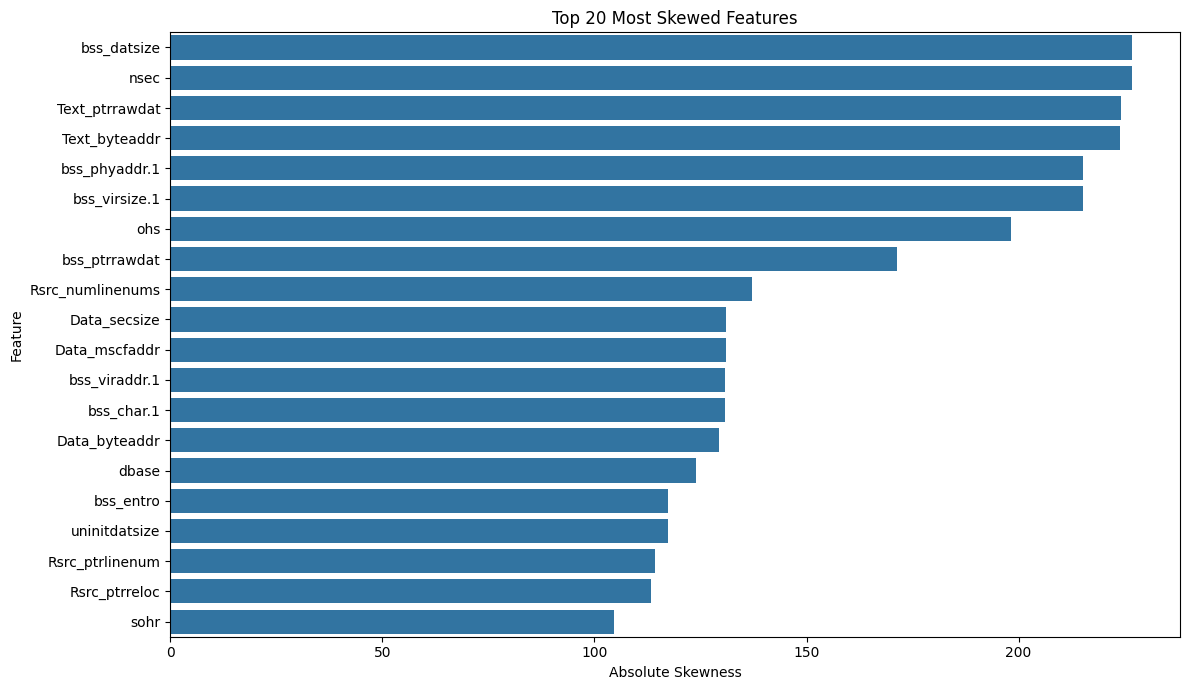

In [54]:
# ============================================================
# CELL 46 — Top 20 Most Skewed Features
# ============================================================

top_skewed = feature_skewness.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_skewed,
    x="Absolute_Skewness",
    y=top_skewed.index
)

plt.title("Top 20 Most Skewed Features")
plt.xlabel("Absolute Skewness")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# CELL 47 — Zero-Value Percentage per Feature
# ============================================================

zero_percentage = (
    (X == 0).mean() * 100
).sort_values(ascending=False)

zero_summary = zero_percentage.to_frame(
    "Zero_Value_Percentage"
)

zero_summary["Zero_Value_Percentage"] = (
    zero_summary["Zero_Value_Percentage"].round(2)
)

display(zero_summary.head(20))

,Zero_Value_Percentage
bss_char.1,99.99
bss_viraddr.1,99.99
bss_virsize.1,99.99
bss_phyaddr.1,99.99
secalign,99.99
bss_datsize,99.99
bss_entro,99.99
ibase,99.99
Data_numlinenums,99.96
Idata_numlinenums,99.96


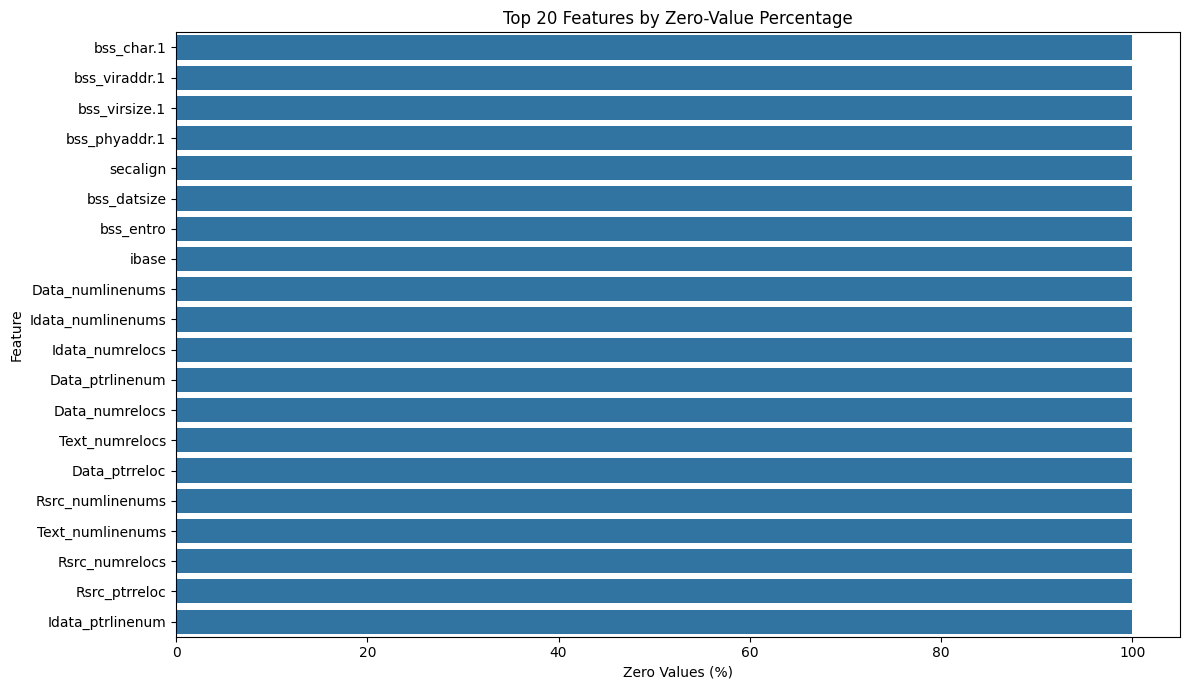

In [56]:
# ============================================================
# CELL 48 — Top 20 Features by Zero-Value Percentage
# ============================================================

top_zero_features = zero_summary.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_zero_features["Zero_Value_Percentage"].values,
    y=top_zero_features.index
)

plt.title("Top 20 Features by Zero-Value Percentage")
plt.xlabel("Zero Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

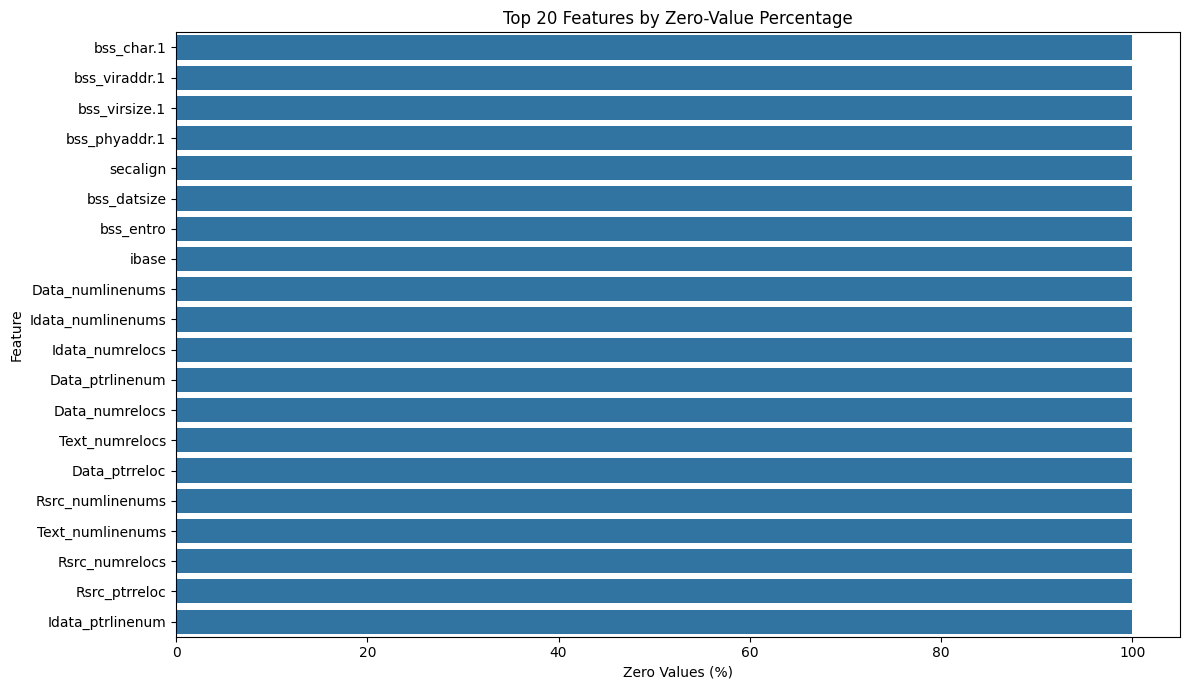

In [57]:
# ============================================================
# CELL 48 — Top 20 Features by Zero-Value Percentage
# ============================================================

top_zero_features = zero_summary.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_zero_features["Zero_Value_Percentage"].values,
    y=top_zero_features.index
)

plt.title("Top 20 Features by Zero-Value Percentage")
plt.xlabel("Zero Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# CELL 49 — Investigate Maximum 32-bit Unsigned Integer Values
# ============================================================

UINT32_MAX = 2**32 - 1

max_value_analysis = pd.DataFrame({
    "Maximum": X.max(),
    "Count_Equal_to_UINT32_MAX": [
        (X[col] == UINT32_MAX).sum()
        for col in X.columns
    ]
})

max_value_analysis["Percentage_Equal_to_UINT32_MAX"] = (
    max_value_analysis["Count_Equal_to_UINT32_MAX"]
    / len(X)
    * 100
).round(4)

max_value_analysis = max_value_analysis[
    max_value_analysis["Count_Equal_to_UINT32_MAX"] > 0
].sort_values(
    "Count_Equal_to_UINT32_MAX",
    ascending=False
)

display(max_value_analysis)

,Maximum,Count_Equal_to_UINT32_MAX,Percentage_Equal_to_UINT32_MAX
stcnt,4.294967e+09,6,0.0117
cbase,4.294967e+09,6,0.0117
ldflg,4.294967e+09,6,0.0117
optcksum,4.294967e+09,1,0.0019
sohr,4.294967e+09,1,0.0019
Text_char,4.294967e+09,1,0.0019


In [59]:
# ============================================================
# CELL 50 — Features with Largest Maximum Values
# ============================================================

top_max_features = (
    X.max()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("Maximum_Value")
)

display(top_max_features)

,Maximum_Value
cbase,4.294967e+09
stcnt,4.294967e+09
sohr,4.294967e+09
optcksum,4.294967e+09
Text_char,4.294967e+09
ldflg,4.294967e+09
Data_ptrreloc,4.294932e+09
Text_ptrlinenum,4.294923e+09
ptrst,4.283477e+09
Text_ptrreloc,4.269998e+09


In [60]:
# ============================================================
# CELL 51 — IQR-Based Outlier Analysis
# ============================================================

outlier_summary = []

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (X[col] < lower_bound) |
        (X[col] > upper_bound)
    )
    
    outlier_count = outlier_mask.sum()
    
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": (
            outlier_count / len(X) * 100
        )
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df["Outlier_Percentage"] = (
    outlier_df["Outlier_Percentage"].round(2)
)

outlier_df = outlier_df.sort_values(
    "Outlier_Percentage",
    ascending=False
)

display(outlier_df.head(20))

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
62,Text_char,1.610613e+09,1.610613e+09,0.000000,1.610613e+09,1.610613e+09,12554,24.42
63,Text_entro,4.783720e+00,6.314442e+00,1.530722,2.487637e+00,8.610525e+00,9746,18.96
66,Idata_byteaddr,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9324,18.14
67,Idata_datsize,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9324,18.14
73,Idata_char,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9324,18.14
68,Idata_ptrrawdat,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9323,18.14
65,Idata_secsize,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9320,18.13
64,Idata_mscfaddr,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9320,18.13
74,Idata_entro,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,9318,18.13
78,Rsrc_datsize,1.536000e+03,1.792000e+04,16384.000000,-2.304000e+04,4.249600e+04,9021,17.55


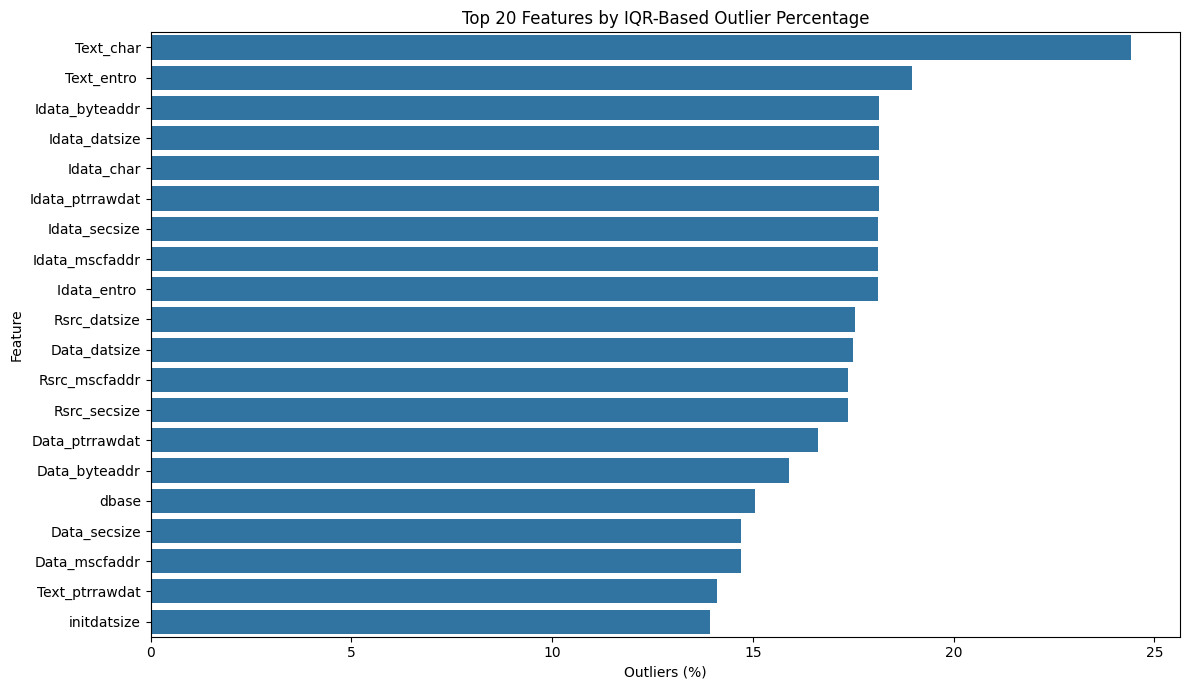

In [61]:
# ============================================================
# CELL 52 — Top 20 Features by IQR Outlier Percentage
# ============================================================

top_outlier_features = outlier_df.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_outlier_features,
    x="Outlier_Percentage",
    y="Feature"
)

plt.title("Top 20 Features by IQR-Based Outlier Percentage")
plt.xlabel("Outliers (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# CELL 53 — Select Representative Features for Distribution Analysis
# ============================================================

representative_features = [
    "blp",
    "Fp",
    "codesize",
    "Data_char"
]

# Keep only features that actually exist
representative_features = [
    col for col in representative_features
    if col in X.columns
]

print("Selected features:")
print(representative_features)

Selected features:
['blp', 'Fp', 'codesize', 'Data_char']


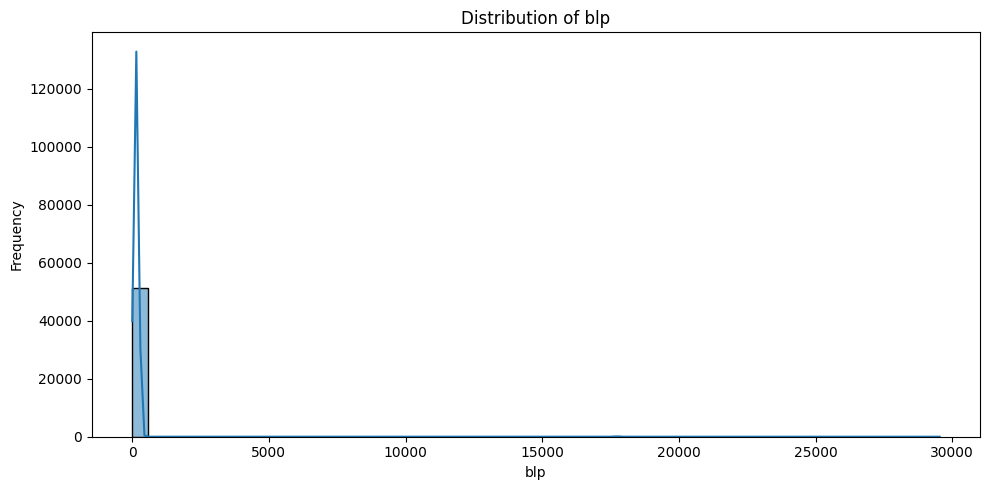

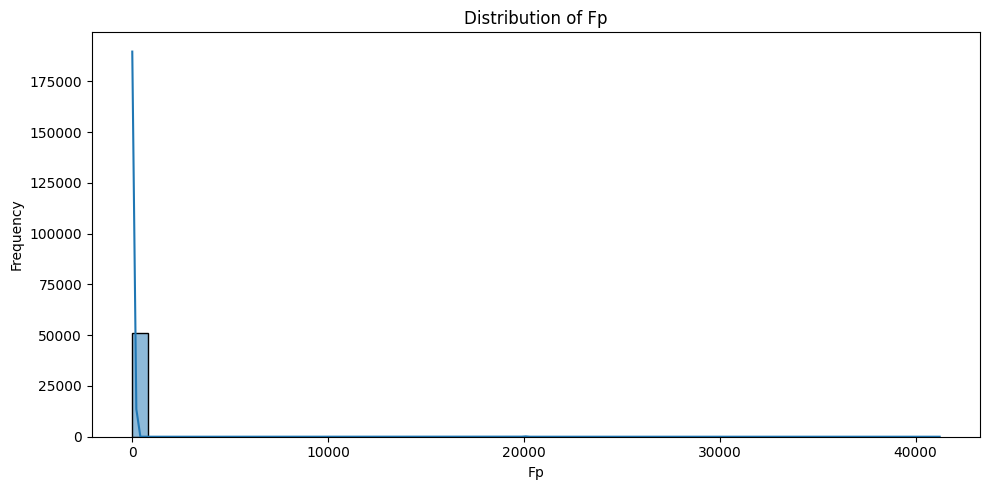

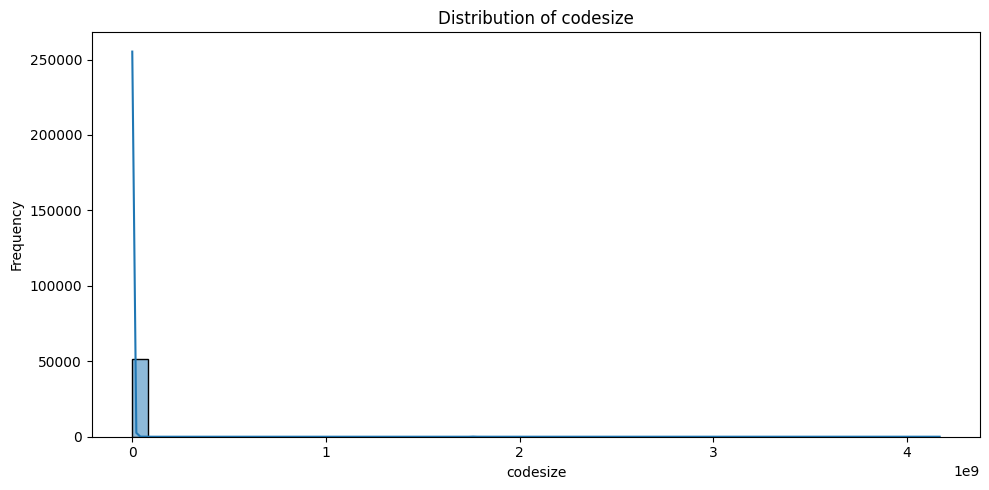

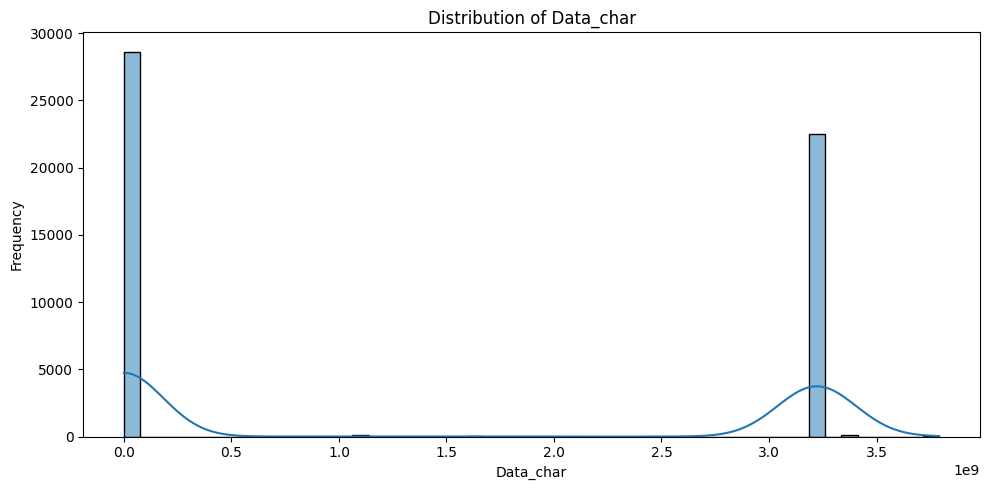

In [63]:
# ============================================================
# CELL 54 — Representative Feature Distributions
# ============================================================

for feature in representative_features:
    
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        X[feature],
        bins=50,
        kde=True
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

In [65]:
# ============================================================
# CELL 55 — Data Quality Summary
# ============================================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Total Features",
        "Missing Values",
        "Duplicate Rows Beyond First Occurrence",
        "Rows Involved in Duplicate Groups",
        "Constant Features",
        "Near-Constant Features (≥99%)",
        "Features with UINT32_MAX Values"
    ],
    "Value": [
        len(df),
        X.shape[1],
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(duplicate_mask.sum()),
        len(constant_features),
        len(near_constant_df),
        len(max_value_analysis)
    ]
})

display(quality_summary)

,Metric,Value
0,Total Samples,51408
1,Total Features,108
2,Missing Values,0
3,Duplicate Rows Beyond First Occurrence,14367
4,Rows Involved in Duplicate Groups,25633
5,Constant Features,0
6,Near-Constant Features (≥99%),36
7,Features with UINT32_MAX Values,6


In [66]:
# ============================================================
# CELL 56 — Interactive Visualization Setup
# ============================================================

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Plotly version:", px.__version__ if hasattr(px, "__version__") else "Installed")
print("Interactive visualization libraries loaded successfully.")

Plotly version: Installed
Interactive visualization libraries loaded successfully.


In [67]:
!pip install plotly -q

In [94]:
# ============================================================
# CELL 57 — Interactive Class Distribution
# ============================================================

class_counts = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .reset_index()
)

class_counts.columns = ["Class", "Count"]

class_counts["Percentage"] = (
    class_counts["Count"] / class_counts["Count"].sum() * 100
).round(2)

fig = px.bar(
    class_counts,
    x="Class",
    y="Count",
    text="Count",
    hover_data=["Percentage"],
    title="Interactive Class Distribution"
)

fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Class",
    yaxis_title="Number of Samples",
    hovermode="x unified"
)

fig.show()

In [71]:
# ============================================================
# CELL 58 — Interactive PCA Visualization
# ============================================================

pca_plot_df = pca_df.copy()

pca_plot_df["Class"] = pca_plot_df["class"].astype(str)

fig = px.scatter(
    pca_plot_df,
    x="PC1",
    y="PC2",
    color="Class",
    opacity=0.55,
    hover_data=["Class"],
    title="Interactive PCA Projection of SOMLAP Feature Space"
)

fig.update_layout(
    xaxis_title=(
        f"PC1 "
        f"({pca_2d.explained_variance_ratio_[0] * 100:.2f}% variance)"
    ),
    yaxis_title=(
        f"PC2 "
        f"({pca_2d.explained_variance_ratio_[1] * 100:.2f}% variance)"
    ),
    legend_title="Class"
)

fig.show()

In [72]:
# ============================================================
# CELL 59 — Interactive Feature Distribution
# ============================================================

feature_for_interactive_plot = "Data_char"

feature_plot_df = pd.DataFrame({
    "Value": X[feature_for_interactive_plot],
    "Class": y.astype(str)
})

fig = px.histogram(
    feature_plot_df,
    x="Value",
    color="Class",
    marginal="box",
    nbins=80,
    opacity=0.65,
    title=f"Interactive Distribution of {feature_for_interactive_plot}",
    hover_data=["Class"]
)

fig.update_layout(
    xaxis_title=feature_for_interactive_plot,
    yaxis_title="Frequency",
    legend_title="Class"
)

fig.show()

In [73]:
# ============================================================
# CELL 60 — Interactive Box Plot
# ============================================================

fig = px.box(
    feature_plot_df,
    x="Class",
    y="Value",
    color="Class",
    points=False,
    title=f"Class-wise Distribution of {feature_for_interactive_plot}"
)

fig.update_layout(
    xaxis_title="Class",
    yaxis_title=feature_for_interactive_plot,
    legend_title="Class"
)

fig.show()

In [74]:
# ============================================================
# CELL 61 — Log-Transformed Interactive Distribution
# ============================================================

log_feature_plot_df = feature_plot_df.copy()

log_feature_plot_df["Log_Value"] = np.log1p(
    log_feature_plot_df["Value"]
)

fig = px.histogram(
    log_feature_plot_df,
    x="Log_Value",
    color="Class",
    marginal="box",
    nbins=80,
    opacity=0.65,
    title=f"Log-Transformed Distribution of {feature_for_interactive_plot}"
)

fig.update_layout(
    xaxis_title=f"log1p({feature_for_interactive_plot})",
    yaxis_title="Frequency",
    legend_title="Class"
)

fig.show()

In [75]:
# ============================================================
# CELL 62 — Feature Correlation Matrix
# ============================================================

correlation_matrix = X.corr()

print("Correlation matrix shape:", correlation_matrix.shape)

display(correlation_matrix.head())

Correlation matrix shape: (108, 108)


,blp,Fp,Rn,Prhdr,Minpar,Maxpar,Ivalss,Ivalsp,doscksum,Iip,Ics,Rta,Ovn,Idoem,Infoem,exehdradr,mach,nsec,tds,ptrst,stcnt,ohs,char,sig,majlv,minlv,codesize,initdatsize,uninitdatsize,adrentpt,cbase,dbase,ibase,secalign,filealign,majosver,minosver,majiver,miniver,majssver,minssver,win32vv,soi,soh,optcksum,ss,dllch,sosr,sosc,sohr,sohc,ldflg,ndirent,Text_mscfaddr,Text_secsize,Text_byteaddr,Text_datsize,Text_ptrrawdat,Text_ptrreloc,Text_ptrlinenum,Text_numrelocs,Text_numlinenums,Text_char,Text_entro,Idata_mscfaddr,Idata_secsize,Idata_byteaddr,Idata_datsize,Idata_ptrrawdat,Idata_ptrreloc,Idata_ptrlinenum,Idata_numrelocs,Idata_numlinenums,Idata_char,Idata_entro,Rsrc_mscfaddr,Rsrc_secsize,Rsrc_byteaddr,Rsrc_datsize,Rsrc_ptrrawdat,Rsrc_ptrreloc,Rsrc_ptrlinenum,Rsrc_numrelocs,Rsrc_numlinenums,Rsrc_char,Rsrc_entro,Data_mscfaddr,Data_secsize,Data_byteaddr,Data_datsize,Data_ptrrawdat,Data_ptrreloc,Data_ptrlinenum,Data_numrelocs,Data_numlinenums,Data_char,Data_entro,bss_phyaddr,bss_virsize,bss_viraddr,bss_datsize,bss_ptrrawdat,bss_char,bss_entro,bss_phyaddr.1,bss_virsize.1,bss_viraddr.1,bss_char.1
blp,1.000000,0.873844,0.882015,0.812401,0.779108,-0.222626,0.041285,0.550987,0.198164,0.257559,0.184025,0.648419,0.153280,0.152783,0.329519,-0.034545,-0.022988,-0.000840,0.026939,0.552259,0.589701,0.035506,-0.007717,-0.022988,0.238047,0.300055,0.529503,0.545173,-0.000446,-0.000757,0.338381,-0.000566,0.036873,-0.000384,-0.000994,0.294613,0.281094,0.216340,0.133220,-0.000581,-0.000568,-0.001120,-0.000781,-0.000398,-0.001757,-0.000484,-0.016137,-0.000434,-0.000451,-0.000958,-0.000434,0.233367,-0.000585,-0.008716,-0.008716,-0.000947,-0.008858,-0.000809,-0.001646,-0.001585,-0.001491,-0.001772,-0.065859,-0.066896,-0.008991,-0.008991,-0.003879,-0.007811,-0.004026,-0.001778,-0.001745,-0.001908,-0.001640,-0.015042,-0.012791,-0.001587,-0.001587,-0.005404,-0.001655,-0.006513,-0.001161,-0.001157,-0.002175,-0.001017,-0.022268,-0.040188,-0.001491,-0.001491,-0.001321,-0.003306,-0.004656,-0.001828,-0.001590,-0.002010,-0.001530,-0.032863,-0.022506,-0.001572,-0.001572,-0.003200,-0.000158,-0.001526,-0.009112,-0.000457,-0.000191,-0.000191,-0.000271,-0.000271
Fp,0.873844,1.000000,0.942350,0.820352,0.893851,-0.243226,0.021166,0.627482,0.226807,0.340933,0.223833,0.760247,0.218454,0.176068,0.261106,-0.034784,-0.022731,-0.000492,0.030579,0.654866,0.600657,0.004580,0.006857,-0.022733,0.203416,0.295103,0.689093,0.684368,0.123321,-0.000829,0.223771,-0.000681,0.042471,-0.000416,-0.000981,0.216519,0.193171,0.153796,0.084027,-0.000630,0.020861,-0.000832,0.006673,-0.000430,0.028742,-0.000520,-0.029144,0.000619,-0.000051,-0.000314,-0.000470,0.150735,-0.000547,-0.007760,-0.007760,-0.000516,-0.007806,-0.000383,-0.000648,-0.000540,-0.000524,-0.000667,-0.064163,-0.070332,-0.007408,-0.007408,-0.003342,-0.007541,-0.003461,-0.000634,-0.000588,-0.000643,-0.000553,-0.010816,-0.012947,-0.001543,-0.001543,-0.005803,-0.001631,-0.006841,-0.000419,-0.000393,-0.000781,-0.000366,-0.027774,-0.045951,-0.001175,-0.001175,-0.000724,-0.002159,-0.004516,-0.000618,-0.000540,-0.000682,-0.000523,-0.029954,-0.020267,-0.001105,-0.001105,-0.002215,-0.000171,-0.000390,-0.006396,-0.000383,-0.000207,-0.000207,-0.000294,-0.000294
Rn,0.882015,0.942350,1.000000,0.876356,0.905399,-0.247059,0.062903,0.609029,0.219787,0.342809,0.222509,0.744387,0.224265,0.170233,0.246000,-0.035136,-0.022464,-0.000487,0.028709,0.639544,0.579879,0.004408,0.006523,-0.022466,0.192140,0.281744,0.678075,0.680326,0.131736,-0.000804,0.201111,-0.000653,0.041128,-0.000412,-0.000967,0.205185,0.175898,0.148323,0.080455,-0.000624,0.015272,-0.000877,0.007831,-0.000426,0.029510,-0.000515,-0.027957,0.000731,0.000006,-0.000285,-0.000466,0.140143,-0.000541,-0.007390,-0.007390,-0.000496,-0.007435,-0.000373,-0.000625,-0.000517,-0.000503,-0.000643,-0.065672,-0.068733,-0.007499,-0.007499,-0.003299,-0.007609,-0.003412,-0.000609,-0.000564,-0.000616,-0.000530,-0.010851,-0.013050,-0.001549,-0.001549,-0.005594,-0.001635,-0.006589,-0.000402,-0.000377,-0.000750,-0

In [76]:
# ============================================================
# CELL 63 — Interactive Correlation Heatmap
# ============================================================

fig = px.imshow(
    correlation_matrix,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Interactive Feature Correlation Heatmap"
)

fig.update_layout(
    width=1100,
    height=900,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

In [77]:
# ============================================================
# CELL 64 — Highly Correlated Feature Pairs
# ============================================================

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

corr_pairs["Absolute_Correlation"] = (
    corr_pairs["Correlation"].abs()
)

high_corr_pairs = (
    corr_pairs[
        corr_pairs["Absolute_Correlation"] >= 0.90
    ]
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print(
    "Number of feature pairs with |correlation| >= 0.90:",
    len(high_corr_pairs)
)

display(high_corr_pairs.head(30))

Number of feature pairs with |correlation| >= 0.90: 26


,Feature_1,Feature_2,Correlation,Absolute_Correlation
4293,Text_mscfaddr,Text_secsize,1.000000,1.000000
4832,Idata_mscfaddr,Idata_secsize,1.000000,1.000000
5250,Rsrc_mscfaddr,Rsrc_secsize,1.000000,1.000000
5547,Data_mscfaddr,Data_secsize,1.000000,1.000000
5772,bss_phyaddr.1,bss_virsize.1,1.000000,1.000000
5723,bss_phyaddr,bss_virsize,1.000000,1.000000
5777,bss_viraddr.1,bss_char.1,1.000000,1.000000
1598,mach,sig,0.999862,0.999862
4401,Text_byteaddr,Text_ptrrawdat,0.999832,0.999832
5252,Rsrc_mscfaddr,Rsrc_datsize,0.998835,0.998835


In [78]:
# ============================================================
# CELL 65 — Very Highly Correlated Feature Pairs
# ============================================================

very_high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Absolute_Correlation"] >= 0.95
].copy()

print(
    "Number of feature pairs with |correlation| >= 0.95:",
    len(very_high_corr_pairs)
)

display(very_high_corr_pairs.head(30))

Number of feature pairs with |correlation| >= 0.95: 19


,Feature_1,Feature_2,Correlation,Absolute_Correlation
4293,Text_mscfaddr,Text_secsize,1.000000,1.000000
4832,Idata_mscfaddr,Idata_secsize,1.000000,1.000000
5250,Rsrc_mscfaddr,Rsrc_secsize,1.000000,1.000000
5547,Data_mscfaddr,Data_secsize,1.000000,1.000000
5772,bss_phyaddr.1,bss_virsize.1,1.000000,1.000000
5723,bss_phyaddr,bss_virsize,1.000000,1.000000
5777,bss_viraddr.1,bss_char.1,1.000000,1.000000
1598,mach,sig,0.999862,0.999862
4401,Text_byteaddr,Text_ptrrawdat,0.999832,0.999832
5252,Rsrc_mscfaddr,Rsrc_datsize,0.998835,0.998835


In [79]:
# ============================================================
# CELL 66 — Top Variance Features for Class Comparison
# ============================================================

top_features_for_comparison = (
    X.var()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

print("Selected features:")
print(top_features_for_comparison)

Selected features:
['Data_char', 'Idata_char', 'bss_char', 'Text_char', 'Rsrc_char', 'ptrst', 'optcksum', 'stcnt', 'ldflg', 'initdatsize']


In [80]:
# ============================================================
# CELL 67 — Class-wise Feature Summary
# ============================================================

class_feature_summary = (
    df.groupby(TARGET_COLUMN)[top_features_for_comparison]
    .median()
    .T
)

display(class_feature_summary)

class,0,1
Data_char,3.221226e+09,0.000000e+00
Idata_char,0.000000e+00,0.000000e+00
bss_char,0.000000e+00,0.000000e+00
Text_char,1.610613e+09,1.610613e+09
Rsrc_char,1.073742e+09,1.073742e+09
ptrst,0.000000e+00,0.000000e+00
optcksum,1.011885e+05,0.000000e+00
stcnt,0.000000e+00,0.000000e+00
ldflg,0.000000e+00,0.000000e+00
initdatsize,2.406400e+04,8.192000e+03


In [81]:
# ============================================================
# CELL 68 — Interactive Class-wise Feature Comparison
# ============================================================

comparison_df = class_feature_summary.reset_index()

comparison_df.columns = [
    "Feature",
    "Class_0_Median",
    "Class_1_Median"
]

comparison_long = comparison_df.melt(
    id_vars="Feature",
    value_vars=[
        "Class_0_Median",
        "Class_1_Median"
    ],
    var_name="Class",
    value_name="Median_Value"
)

fig = px.bar(
    comparison_long,
    x="Feature",
    y="Median_Value",
    color="Class",
    barmode="group",
    title="Interactive Class-wise Median Comparison of Top-Variance Features"
)

fig.update_layout(
    xaxis_title="Feature",
    yaxis_title="Median Value",
    xaxis_tickangle=-45
)

fig.show()

In [96]:
# ============================================================
# CELL 69 — Interactive Distribution of a Selected Feature
# ============================================================

import numpy as np
import pandas as pd
import plotly.express as px

# Select a meaningful feature automatically
candidate_features = [
    "Text_char",
    "Text_entro",
    "Data_char",
    "bss_datsize",
    "nsec"
]

# Pick the first candidate that exists
feature_for_plot = next(
    (feature for feature in candidate_features if feature in df.columns),
    df.select_dtypes(include=np.number).columns[0]
)

print("Selected feature for interactive visualization:", feature_for_plot)

# Create interactive histogram
fig = px.histogram(
    df,
    x=feature_for_plot,
    color="class" if "class" in df.columns else None,
    nbins=80,
    opacity=0.65,
    marginal="box",
    title=f"Interactive Distribution of {feature_for_plot}",
    labels={
        feature_for_plot: feature_for_plot,
        "class": "Class"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600,
    bargap=0.05
)

fig.show()

Selected feature for interactive visualization: Text_char


In [89]:
# ============================================================
# CELL 70 — Verify Saved Interactive Plot Files
# ============================================================

for root, dirs, files in os.walk(interactive_dir):
    for file in files:
        print(
            os.path.join(root, file)
        )

/kaggle/working/interactive_plots/01_class_distribution.html
/kaggle/working/interactive_plots/02_pca_projection.html


In [85]:
# ============================================================
# CELL 71 — Final EDA Summary
# ============================================================

total_samples = len(df)
total_features = df.drop(columns=["class"]).shape[1]

missing_values = int(
    df.isnull().sum().sum()
)

duplicate_rows = int(
    df.duplicated().sum()
)

constant_features = int(
    (
        df.drop(columns=["class"]).nunique() == 1
    ).sum()
)

near_constant_features = int(
    (
        df.drop(columns=["class"])
        .apply(
            lambda col: col.value_counts(
                normalize=True
            ).iloc[0]
        ) >= 0.99
    ).sum()
)

uint32_max = 2**32 - 1

uint32_max_feature_count = int(
    (
        df.drop(columns=["class"]) == uint32_max
    ).any(axis=0).sum()
)

summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Total Features",
        "Number of Classes",
        "Missing Values",
        "Duplicate Rows Beyond First Occurrence",
        "Duplicate Percentage",
        "Constant Features",
        "Near-Constant Features (>=99%)",
        "Features Containing UINT32_MAX"
    ],
    "Value": [
        total_samples,
        total_features,
        df["class"].nunique(),
        missing_values,
        duplicate_rows,
        round(
            duplicate_rows /
            total_samples * 100,
            2
        ),
        constant_features,
        near_constant_features,
        uint32_max_feature_count
    ]
})

display(summary)

,Metric,Value
0,Total Samples,51408.00
1,Total Features,108.00
2,Number of Classes,2.00
3,Missing Values,0.00
4,Duplicate Rows Beyond First Occurrence,14367.00
5,Duplicate Percentage,27.95
6,Constant Features,0.00
7,Near-Constant Features (>=99%),36.00
8,Features Containing UINT32_MAX,6.00


In [97]:
# ============================================================
# CELL 72 — Class Distribution and Imbalance Analysis
# ============================================================

class_summary = (
    df["class"]
    .value_counts()
    .sort_index()
    .to_frame(name="Count")
)

# Percentage
class_summary["Percentage"] = (
    class_summary["Count"] / len(df) * 100
).round(2)

# Majority / minority
majority_count = class_summary["Count"].max()
minority_count = class_summary["Count"].min()

# Imbalance ratio
imbalance_ratio = round(
    majority_count / minority_count,
    3
)

class_summary["Majority_to_Minority_Ratio"] = imbalance_ratio

display(class_summary)

print("\nClass imbalance interpretation:")
print(f"Majority class count : {majority_count:,}")
print(f"Minority class count : {minority_count:,}")
print(f"Majority-to-minority ratio : {imbalance_ratio}:1")

if imbalance_ratio < 1.5:
    print("Interpretation: The dataset is relatively balanced.")
elif imbalance_ratio < 2:
    print("Interpretation: The dataset shows mild class imbalance.")
else:
    print("Interpretation: The dataset shows noticeable class imbalance.")

,Count,Percentage,Majority_to_Minority_Ratio
class,,,
0,31600,61.47,1.595
1,19808,38.53,1.595



Class imbalance interpretation:
Majority class count : 31,600
Minority class count : 19,808
Majority-to-minority ratio : 1.595:1
Interpretation: The dataset shows mild class imbalance.


In [87]:
# ============================================================
# CELL 73 — Duplicate Analysis Summary by Class
# ============================================================

duplicate_mask = df.duplicated(keep=False)

duplicate_class_summary = (
    df.groupby("class")
    .apply(
        lambda group: pd.Series({
            "Total_Samples": len(group),
            "Rows_in_Duplicate_Groups": int(
                duplicate_mask.loc[group.index].sum()
            ),
            "Unique_or_NonDuplicated": int(
                len(group) -
                duplicate_mask.loc[group.index].sum()
            )
        }),
        include_groups=False
    )
)

duplicate_class_summary[
    "Duplicate_Group_Rate_%"
] = (
    duplicate_class_summary[
        "Rows_in_Duplicate_Groups"
    ] /
    duplicate_class_summary[
        "Total_Samples"
    ] * 100
).round(2)

display(
    duplicate_class_summary
)

,Total_Samples,Rows_in_Duplicate_Groups,Unique_or_NonDuplicated,Duplicate_Group_Rate_%
class,,,,
0,31600,23647,7953,74.83
1,19808,1986,17822,10.03


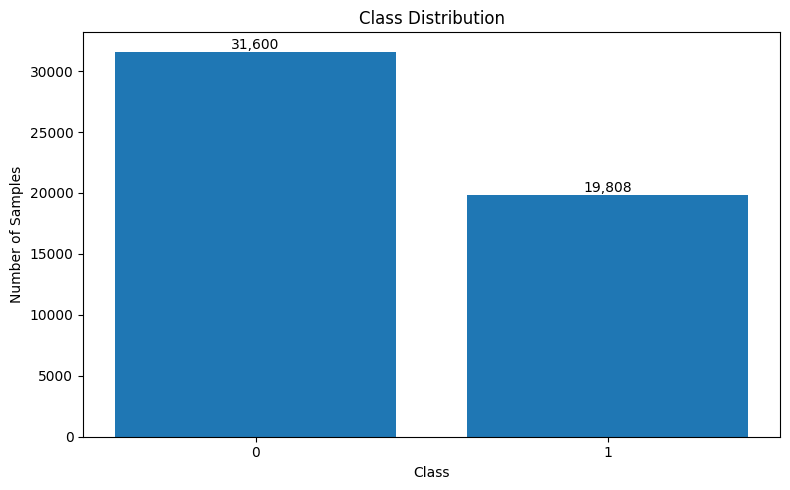

In [98]:
# ============================================================
# CELL 73.1 — Class Distribution Visualization
# ============================================================

import matplotlib.pyplot as plt

counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

# Add count labels
for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [99]:
# ============================================================
# CELL 74 — FINAL EDA FINDINGS
# ============================================================

print("=" * 70)
print("FINAL EDA FINDINGS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset size
# ------------------------------------------------------------

n_samples = df.shape[0]
n_features = df.shape[1] - 1

print("\n1. Dataset size:")
print(f"   {n_samples:,} samples × {n_features} features")


# ------------------------------------------------------------
# 2. Target
# ------------------------------------------------------------

target_column = "class"

classes = sorted(df[target_column].unique())

print("\n2. Target:")
print("   Binary classification")
print(f"   Classes: {classes}")


# ------------------------------------------------------------
# 3. Missing values
# ------------------------------------------------------------

missing_total = df.isnull().sum().sum()

print("\n3. Missing values:")
print(f"   {missing_total:,} missing values found.")


# ------------------------------------------------------------
# 4. Duplicate observations
# ------------------------------------------------------------

duplicate_rows = df.duplicated().sum()

duplicate_percentage = (
    duplicate_rows / len(df) * 100
)

print("\n4. Duplicate observations:")
print(
    f"   {duplicate_rows:,} duplicate rows beyond first occurrence "
    f"({duplicate_percentage:.2f}%)."
)


# ------------------------------------------------------------
# 5. Constant features
# ------------------------------------------------------------

constant_features = [
    col for col in df.drop(columns=[target_column]).columns
    if df[col].nunique(dropna=False) <= 1
]

print("\n5. Constant features:")
print(f"   {len(constant_features)} constant features.")


# ------------------------------------------------------------
# 6. Near-constant features
# ------------------------------------------------------------

X = df.drop(columns=[target_column])

near_constant_features = []

for col in X.columns:
    
    dominant_ratio = (
        X[col].value_counts(normalize=True, dropna=False).iloc[0]
    )
    
    if dominant_ratio >= 0.99:
        near_constant_features.append(col)

print("\n6. Near-constant features:")
print(
    f"   {len(near_constant_features)} features have "
    f">=99% of observations at the same value."
)


# ------------------------------------------------------------
# 7. UINT32_MAX values
# ------------------------------------------------------------

UINT32_MAX = 2**32 - 1

uint32_features = []

for col in X.columns:
    
    if (X[col] == UINT32_MAX).any():
        uint32_features.append(col)

print("\n7. UINT32_MAX values:")
print(
    f"   {len(uint32_features)} features contain "
    f"the value {UINT32_MAX:,}."
)


# ------------------------------------------------------------
# 8. PCA
# ------------------------------------------------------------

# Use the PCA result already generated earlier if available.
# Otherwise calculate PCA safely.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_numeric = X.select_dtypes(include=np.number).copy()

# Replace inf values if any
X_numeric = X_numeric.replace(
    [np.inf, -np.inf],
    np.nan
)

# Median imputation only for PCA calculation
X_numeric = X_numeric.fillna(X_numeric.median())

# Standardization
scaler_final = StandardScaler()

X_scaled_final = scaler_final.fit_transform(X_numeric)

# PCA
pca_final = PCA()

X_pca_final = pca_final.fit_transform(X_scaled_final)

cumulative_variance = np.cumsum(
    pca_final.explained_variance_ratio_
) * 100

variance_2 = cumulative_variance[1]

# Find number of components for thresholds
def components_for_variance(cumulative, threshold):
    return np.argmax(cumulative >= threshold) + 1

components_80 = components_for_variance(
    cumulative_variance,
    80
)

components_90 = components_for_variance(
    cumulative_variance,
    90
)

components_95 = components_for_variance(
    cumulative_variance,
    95
)

print("\n8. PCA:")

print(
    f"   First 2 PCs explain approximately "
    f"{variance_2:.2f}% of total standardized variance."
)

print(
    f"   Components required for 80% variance: "
    f"{components_80}"
)

print(
    f"   Components required for 90% variance: "
    f"{components_90}"
)

print(
    f"   Components required for 95% variance: "
    f"{components_95}"
)


# ------------------------------------------------------------
# 9. Class balance
# ------------------------------------------------------------

class_counts = df[target_column].value_counts()

majority_count = class_counts.max()
minority_count = class_counts.min()

ratio = majority_count / minority_count

print("\n9. Class balance:")

for cls, count in class_counts.sort_index().items():
    percentage = count / len(df) * 100
    
    print(
        f"   Class {cls}: {count:,} samples "
        f"({percentage:.2f}%)"
    )

print(
    f"   Majority-to-minority ratio: "
    f"{ratio:.3f}:1"
)


# ------------------------------------------------------------
# 10. Overall interpretation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OVERALL INTERPRETATION")
print("=" * 70)

print("""
• The dataset is a binary classification problem with two classes.

• No missing values were detected, so missing-value imputation is not
  required for the original dataset.

• A substantial number of duplicated observations are present.
  Therefore, duplicate handling must be considered carefully before
  model training to avoid data leakage.

• No constant features were detected.

• Several near-constant features were identified. These features may
  provide limited discriminative information and should be evaluated
  before model development.

• The feature distributions are highly right-skewed for several
  PE-header-related variables, indicating the presence of extreme
  values and highly concentrated zero-valued observations.

• The dataset has noticeable but not extreme class imbalance.

• PCA indicates that a relatively large number of principal components
  are required to preserve most of the standardized variance. This
  suggests that the original feature space contains substantial
  multidimensional information.
""")

print("=" * 70)

FINAL EDA FINDINGS

1. Dataset size:
   51,408 samples × 108 features

2. Target:
   Binary classification
   Classes: [np.int64(0), np.int64(1)]

3. Missing values:
   0 missing values found.

4. Duplicate observations:
   14,367 duplicate rows beyond first occurrence (27.95%).

5. Constant features:
   0 constant features.

6. Near-constant features:
   36 features have >=99% of observations at the same value.

7. UINT32_MAX values:
   6 features contain the value 4,294,967,295.

8. PCA:
   First 2 PCs explain approximately 18.05% of total standardized variance.
   Components required for 80% variance: 29
   Components required for 90% variance: 43
   Components required for 95% variance: 54

9. Class balance:
   Class 0: 31,600 samples (61.47%)
   Class 1: 19,808 samples (38.53%)
   Majority-to-minority ratio: 1.595:1

OVERALL INTERPRETATION

• The dataset is a binary classification problem with two classes.

• No missing values were detected, so missing-value imputation is not
  re